In [1]:
%load_ext autoreload
# %load_ext kedro.ipython
%load_ext kedro.extras.extensions.ipython
# %reload_kedro
# %autoreload 2
%config Completer.use_jedi = False  ## (To fix autocomplete)

import matplotlib
matplotlib.use('QtAgg')  # kein GUI-Fenster, nur Dateien speichern
import matplotlib.pyplot as plt
from plot.plot import *
import pandas as pd
import numpy as np
import Krylov.krylov as kry

from scipy.signal import medfilt

2026-06-27 16:32:43,888 - kedro.framework.session.store - INFO - `read()` not implemented for `SQLiteStore`. Assuming empty store.


/home/sim/Documents/git_repos/SI_VMM/System-identification-of-Vessel-Manoeuvring-Models/.venv/lib/python3.10/site-packages/kedro/framework/context/context.py:488: UserWarning: Credentials not found in your Kedro project config.
No files found in ['/home/sim/Documents/git_repos/SI_VMM/System-identification-of-Vessel-Manoeuvring-Models/conf/base', '/home/sim/Documents/git_repos/SI_VMM/System-identification-of-Vessel-Manoeuvring-Models/conf/local'] matching the glob pattern(s): ['credentials*', 'credentials*/**', '**/credentials*']
  warn(f"Credentials not found in your Kedro project config.\n{str(exc)}")
/home/sim/Documents/git_repos/SI_VMM/System-identification-of-Vessel-Manoeuvring-Models/.venv/lib/python3.10/site-packages/fsspec/spec.py:92: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  if pa_version and LooseVersion(pa_version) < LooseVersion("2.0"):
/home/sim/Documents/git_repos/SI_VMM/System-identification-of-Vessel-Manoeuvring-Models

2026-06-27 16:32:47,618 - root - INFO - ** Kedro project wPCC_pipeline
2026-06-27 16:32:47,620 - root - INFO - Defined global variable `context`, `session`, `catalog` and `pipelines`
2026-06-27 16:32:48,872 - root - INFO - Registered line magic `run_viz`


/home/sim/Documents/git_repos/SI_VMM/System-identification-of-Vessel-Manoeuvring-Models/src/Krylov/krylov.py:1236: DeprecationWarning: invalid escape sequence '\s'
  prop_openwater = pd.read_csv(f, sep='\s+', header=None, names=['J', 'KT', 'KQ'])


In [2]:
%reload_kedro
kry_p = catalog.load("wlfa.krylov_parameters")
ship_parameters = catalog.load("wlfa.ship_data")
ship_resistance = catalog.load("wlfa.ship_resistance_HM")
prop_openwater = catalog.load("wlfa.prop_openwater")
trial_segmentation = catalog.load("wlfa.segmentation")
# data = map_data(data, )
# data_plot = TelemetryPlotter(data, t_unit="ns", timecolumn="index", relative_time=True, sensor=False)

2026-06-27 16:32:49,304 - kedro.framework.session.store - INFO - `read()` not implemented for `SQLiteStore`. Assuming empty store.


/home/sim/Documents/git_repos/SI_VMM/System-identification-of-Vessel-Manoeuvring-Models/.venv/lib/python3.10/site-packages/kedro/framework/context/context.py:488: UserWarning: Credentials not found in your Kedro project config.
No files found in ['/home/sim/Documents/git_repos/SI_VMM/System-identification-of-Vessel-Manoeuvring-Models/conf/base', '/home/sim/Documents/git_repos/SI_VMM/System-identification-of-Vessel-Manoeuvring-Models/conf/local'] matching the glob pattern(s): ['credentials*', 'credentials*/**', '**/credentials*']
  warn(f"Credentials not found in your Kedro project config.\n{str(exc)}")


2026-06-27 16:32:50,124 - root - INFO - ** Kedro project wPCC_pipeline
2026-06-27 16:32:50,125 - root - INFO - Defined global variable `context`, `session`, `catalog` and `pipelines`
2026-06-27 16:32:50,136 - root - INFO - Registered line magic `run_viz`
2026-06-27 16:32:50,137 - kedro.io.data_catalog - INFO - Loading data from `wlfa.krylov_parameters` (YAMLDataSet)...
2026-06-27 16:32:50,155 - kedro.io.data_catalog - INFO - Loading data from `wlfa.ship_data` (YAMLDataSet)...
2026-06-27 16:32:50,160 - kedro.io.data_catalog - INFO - Loading data from `wlfa.ship_resistance_HM` (CSVDataSet)...
2026-06-27 16:32:50,164 - kedro.io.data_catalog - INFO - Loading data from `wlfa.prop_openwater` (CSVDataSet)...
2026-06-27 16:32:50,167 - kedro.io.data_catalog - INFO - Loading data from `wlfa.segmentation` (ParquetDataSet)...


# loading data depening on segmentation iloc

In [3]:
trial_name = f"wlfa.{trial_segmentation.iloc[1]['segment_name']}"
data = catalog.load(trial_name)

2026-06-27 16:32:50,206 - kedro.io.data_catalog - INFO - Loading data from `wlfa.ZZ_10.0_10.0_b_190.0_35.0_rpm_ps_turn` (ParquetDataSet)...


In [4]:
input_columns_data = [
    "rpm_response_ps", "rpm_response_stb",
    "azimuth_response_ps", "azimuth_response_stb"
]
print(data.index[:3], data.index[-3:])



kf = kry.Krylov_forces(
                    ship_parameters=ship_parameters, 
                    krylov_parameters=kry_p, 
                    ship_resistance=ship_resistance, 
                    prop_openwater=prop_openwater, 
                    data=data
                    )

kf.map_column_names_for_simulation(
    input_columns_data=input_columns_data,
    geopos=["latitude", "longitude"],
)

kf.data["delta_r1"] = kf.data["delta_r0"]




for col in ["delta_r0", "delta_r1", "N0", "N1"]:
    kf.data[col] = medfilt(kf.data[col], kernel_size=7)


for col in ["N0", "N1"]:
    kf.data[col] = kf.data[col]*10

print(kf.data["N0"])


kf.data.index = kf.data.index / 1e9
print(kf.data.index[:3], kf.data.index[-3:])
x0_ = kf.get_x0(sog_col="SOG", cog_col="COG", heading_col="heading", rot_col="rate_of_turn")
x0_test = [0]*6
x0_test[3] = x0_[3]

print(x0_test)

df = kf.simulate(x0_test)


# df.reset_index(inplace=True)
# print(df.index[:3], df.index[-3:])





Int64Index([0, 6428669, 44413424], dtype='int64', name='timestamp_ns') Int64Index([199907405993, 199938285658, 199941035862], dtype='int64', name='timestamp_ns')
timestamp_ns
0               440.0
6428669         440.0
44413424        440.0
44482055        440.0
44536677        440.0
                ...  
199900934711     40.0
199901420139     40.0
199907405993     40.0
199938285658     40.0
199941035862     40.0
Name: N0, Length: 17760, dtype: float64
Float64Index([0.0, 0.006428669, 0.044413424], dtype='float64', name='timestamp_ns') Float64Index([199.907405993, 199.938285658, 199.941035862], dtype='float64', name='timestamp_ns')
[0, 0, 0, 1.0700534660303362, 0, 0]
Initializing simulation with Krylov forces...


Starting integration...
Integration completed.
Execution time: 6.71247410774231 seconds


In [5]:
print(df.keys())

Index(['x0', 'y0', 'psi', 'u', 'v', 'r', 'N0', 'N1', 'delta_r0', 'delta_r1',
       'kr_X', 'kr_Y', 'kr_N', 'pod_X', 'pod_Y', 'pod_N', 'F_X', 'F_Y', 'M_N'],
      dtype='object')


In [6]:
print(df.index.name)
df.reset_index(inplace=True)
df_plot = TelemetryPlotter(df, t_unit="s", timecolumn="index", relative_time=True, sensor=False)

None


type: <class 'int'>, <class 'numpy.float64'>
Filtering window: 0 → 17759, rows selected.


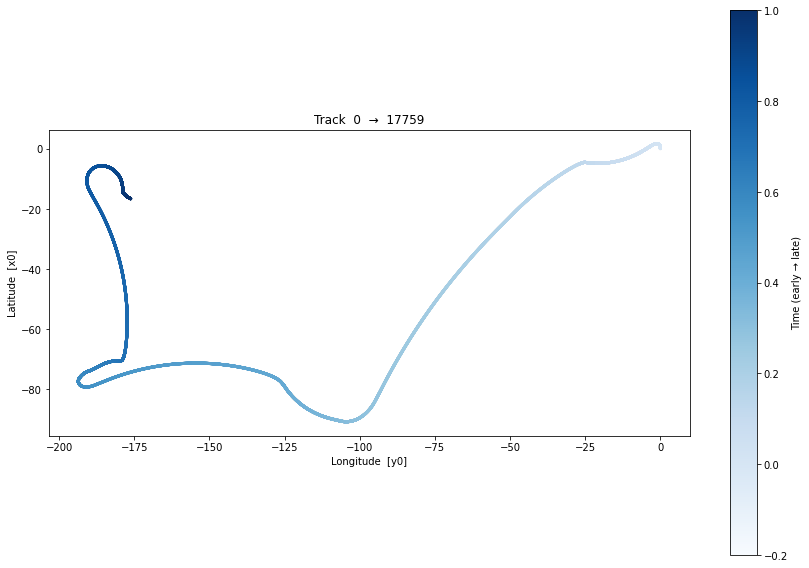

In [7]:
%matplotlib inline

# df_plot.plot_azimuth(start= 0, end = df.index[-1], columns= ["psi"], heading_col= "psi", figsize= (12, 8), invert_y= False)
df_plot.plot_track(start= df.index[0], end = df.index[-1], lat_col= "x0", lon_col="y0", figsize= (12, 8), invert_y= False)
# display(df)

In [8]:
print(df["u"].min(), df["u"].max())

-3.74944010241317 1.0700534660303362


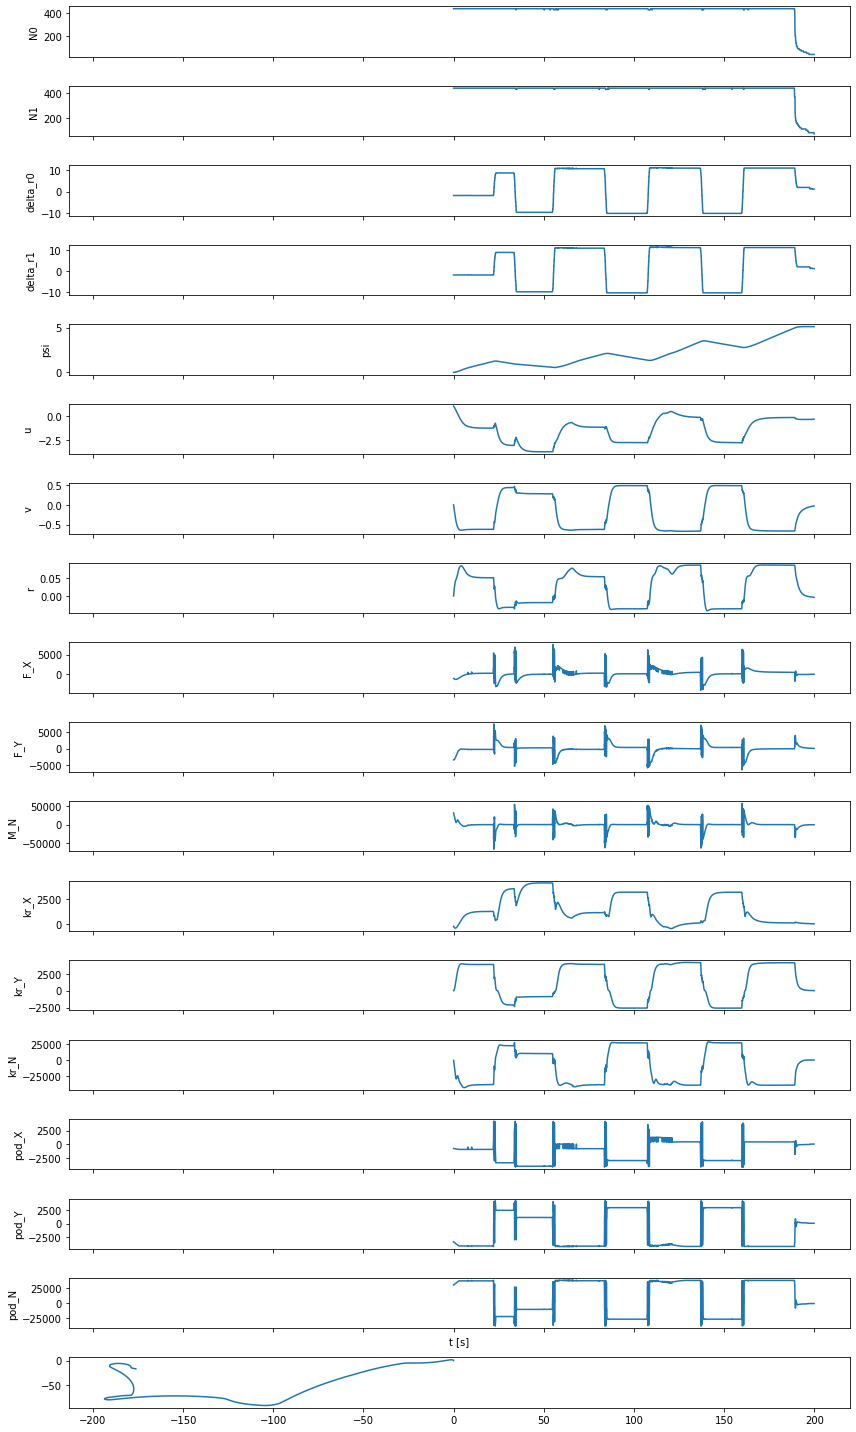

In [9]:
columns = ["N0", "N1", "delta_r0", "delta_r1", "psi", "u", "v", "r", "F_X", "F_Y", "M_N", "kr_X", "kr_Y", "kr_N", "pod_X", "pod_Y", "pod_N"]
fig, axes = plt.subplots(len(columns)+1, 1, figsize=(12, 20), sharex=True)

for ax, col in zip(axes, columns):
    ax.plot(df["index"], df[col])
    ax.set_ylabel(col)

axes[-1].plot(df["y0"], df["x0"])

axes[-2].set_xlabel("t [s]")

fig.tight_layout()
plt.show()